# 05 Predictor Agreement

Question: Do predictors agree more than annotations do?

This notebook summarizes pairwise agreement between human-proteome predictor outputs and compares that agreement with the experimental annotation-agreement estimates from the annotation ceiling analysis.

## Method

Goal: compare whether trained disorder predictors agree more strongly with each other than the experimental annotation sources behind the corresponding UdonPred dataset-specific models.

This is not an accuracy benchmark against a single ground truth. It is a diagnostic comparison between two agreement levels:

1. Predictor agreement on the human proteome
2. Annotation agreement on overlapping experimentally annotated proteins/residues

The predictor comparison uses matched residues from the same human proteome proteins. For every predictor pair, the script reports residue-level Spearman/Pearson correlation, protein-mean Spearman/Pearson correlation, and z-score MAE. CheZOD, pLDDT, and ADOPT are negated before comparison because their native direction is lower = more disorder.

The annotation comparison joins each UdonPred predictor pair to the matching annotation-ceiling pair. Annotation values come from the original experimental label datasets and are computed only on proteins/residues that overlap between those datasets, not on the human proteome predictions.

The main diagnostic is the difference between predictor Spearman and annotation Spearman. Positive values mean the trained predictors agree more strongly on the human proteome than the underlying experimental annotations agree on their overlapping labeled data. This should be interpreted as model-output convergence, not as proof that the models are better than the annotations.

In [7]:
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RESULTS = ROOT / "results"
OUTPUT_DIR = RESULTS / "compare_predictors_with_all_predictors_wo_pdbflex"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pairwise_csv = OUTPUT_DIR / "pairwise_agreement.csv"
contested_csv = OUTPUT_DIR / "contested_regions.csv"

predictor_args = [
    "trizod=results/human_proteome/UdonPred/trizod",
    "chezod=results/human_proteome/UdonPred/chezod",
    "softdis=results/human_proteome/UdonPred/softdis",
    "atlas=results/human_proteome/UdonPred/atlas",
    "plddt=results/human_proteome/UdonPred/plddt",
    "disprot=results/human_proteome/UdonPred/disprot",
    "SETH=results/human_proteome/SETH/seth_human_proteome.caid",
    "IUPred3=results/human_proteome/IUPred3",
    "ADOPT=results/human_proteome/ADOPT",
    "metapredict=results/human_proteome/metapredict/metapredict_human_proteome.caid",
    "PUNCH2_light=results/human_proteome/punch2_light/disorder",
    "DisoFLAG=results/human_proteome/DisoFLAG/caid",
    "DisorderUnetLM=results/human_proteome/DisorderUnetLM/disorder",
    "DisPredict3=results/human_proteome/DisPredict3_native/caid",
]

required_pairwise_columns = {
    "residue_zscore_mae_std",
    "residue_zscore_mae_se",
    "protein_zscore_mae_std",
    "protein_zscore_mae_se",
}
needs_pairwise_update = (
    not pairwise_csv.exists()
    or not required_pairwise_columns.issubset(pd.read_csv(pairwise_csv, nrows=0).columns)
)

if not needs_pairwise_update and contested_csv.exists():
    print("Predictor comparison results already exist, skipping computation.")
else:
    print("Running predictor comparison...")
    cmd = [sys.executable, str(ROOT / "scripts" / "compare_predictors.py")]
    for value in predictor_args:
        cmd.extend(["--predictor", value])
    cmd.extend(["--output-dir", str(OUTPUT_DIR)])
    result = subprocess.run(cmd, cwd=ROOT, text=True, capture_output=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
    result.check_returncode()

pairwise = pd.read_csv(pairwise_csv)
contested_regions = pd.read_csv(contested_csv)

pairwise.head()

Predictor comparison results already exist, skipping computation.


,predictor_a,predictor_b,common_proteins,matched_residues,residue_spearman,residue_pearson,residue_zscore_mae,protein_spearman,protein_pearson,protein_zscore_mae
0,ADOPT,DisPredict3,20596,9816662,0.641354,0.482576,0.750124,0.556213,0.504331,0.721921
1,ADOPT,DisoFLAG,20195,9387303,0.698514,0.708721,0.574584,0.748291,0.698079,0.552899
2,ADOPT,DisorderUnetLM,20659,9861047,0.721924,0.629393,0.645205,0.740520,0.733112,0.527358
3,ADOPT,IUPred3,20659,9861047,0.637572,0.712196,0.600289,0.704414,0.741337,0.539165
4,ADOPT,PUNCH2_light,20077,9376709,0.802041,0.863447,0.389959,0.910071,0.922457,0.281449


## Predictor-Predictor Agreement

Residue-level correlation asks whether predictors rank individual residues similarly. Protein-level correlation asks whether they agree on which proteins are globally more disorder-prone.

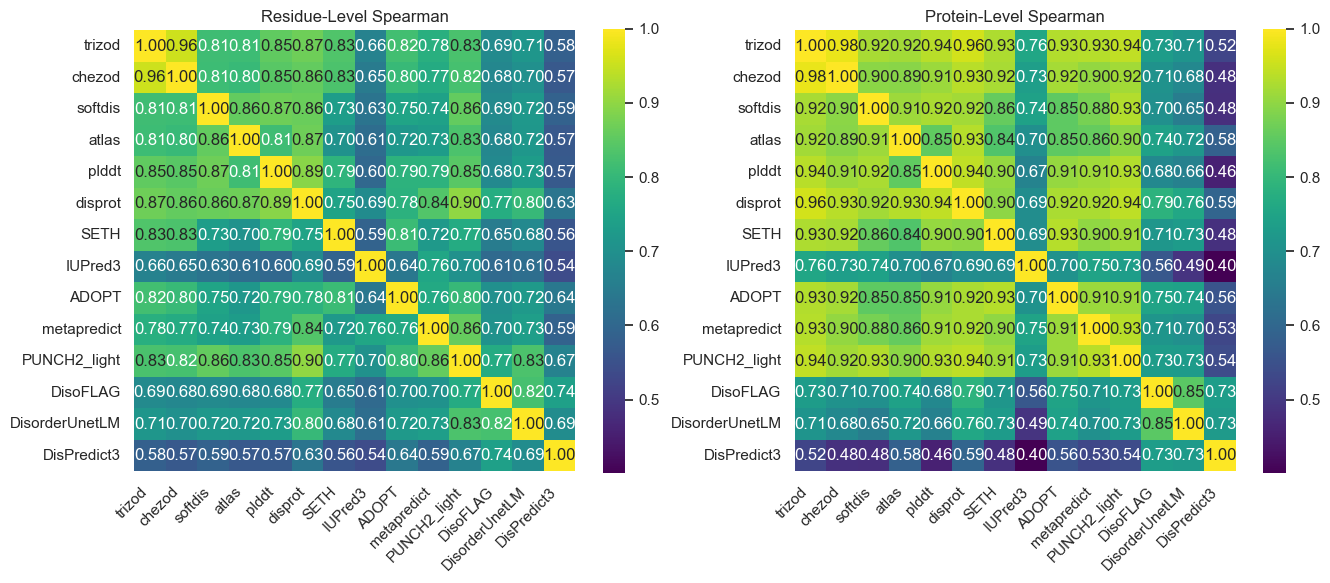

,predictor_a,predictor_b,common_proteins,matched_residues,residue_spearman,residue_pearson,residue_zscore_mae,protein_spearman,protein_pearson,protein_zscore_mae
80,chezod,trizod,20659,11456702,0.955227,0.962036,0.221924,0.980046,0.982735,0.139842
58,PUNCH2_light,disprot,20077,9987102,0.900062,0.930445,0.242028,0.941182,0.930652,0.235208
82,disprot,plddt,20659,11456702,0.894091,0.940588,0.249930,0.942352,0.927614,0.276945
88,plddt,softdis,20659,11456702,0.868132,0.910745,0.303695,0.923485,0.918080,0.262247
84,disprot,trizod,20659,11456702,0.867406,0.938770,0.246672,0.958151,0.954381,0.206561
...,...,...,...,...,...,...,...,...,...,...
22,DisPredict3,plddt,20596,11187995,0.569205,0.413348,0.779545,0.455389,0.352845,0.829116
19,DisPredict3,chezod,20596,11187995,0.566217,0.427794,0.804589,0.484226,0.478297,0.749716
18,DisPredict3,atlas,20596,11187995,0.565430,0.436458,0.679693,0.584698,0.585324,0.694129
17,DisPredict3,SETH,20596,11187995,0.558666,0.439671,0.774066,0.484170,0.498307,0.724232


In [8]:
predictor_order = [
    name
    for name in ["trizod", "chezod", "softdis", "atlas", "plddt", "disprot", "SETH", "IUPred3", "ADOPT", "metapredict", "PUNCH2_light", "DisoFLAG", "DisorderUnetLM", "DisPredict3"]
    if name in set(pairwise["predictor_a"]) | set(pairwise["predictor_b"])
]

def pair_matrix(value_column):
    matrix = pd.DataFrame(np.nan, index=predictor_order, columns=predictor_order)
    for predictor in predictor_order:
        matrix.loc[predictor, predictor] = 1.0
    for row in pairwise.itertuples(index=False):
        matrix.loc[row.predictor_a, row.predictor_b] = getattr(row, value_column)
        matrix.loc[row.predictor_b, row.predictor_a] = getattr(row, value_column)
    return matrix

residue_spearman_matrix = pair_matrix("residue_spearman")
protein_spearman_matrix = pair_matrix("protein_spearman")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(
    residue_spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=np.min([np.nanmin(residue_spearman_matrix.values),np.nanmin(protein_spearman_matrix.values)]),
    vmax=1,
    square=True,
    ax=axes[0],
)
axes[0].set_title("Residue-Level Spearman")
sns.heatmap(
    protein_spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=np.min([np.nanmin(residue_spearman_matrix.values),np.nanmin(protein_spearman_matrix.values)]),
    vmax=1,
    square=True,
    ax=axes[1],
)
axes[1].set_title("Protein-Level Spearman")
# Rotate x tick labels so long labels are visible
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
fig.tight_layout()
# Increase margins to give room for rotated labels
fig.subplots_adjust(bottom=0.22, left=0.18)
fig.savefig(OUTPUT_DIR / "predictor_spearman_heatmaps.png", dpi=210, bbox_inches='tight', pad_inches=0.05)
plt.show()

pairwise.sort_values("residue_spearman", ascending=False)

### Why Is DisPredict3 Agreement Lower at Protein Level?

Protein-level Spearman correlation is calculated after averaging all residue scores within each protein. For a more direct comparison, the following analysis asks how many of the proteins placed in the top 10% by DisPredict3 are also placed in the top 10% by another predictor.

A value of 100% means that both predictors select exactly the same proteins. Approximately 10% overlap is expected for two unrelated top-10% selections.

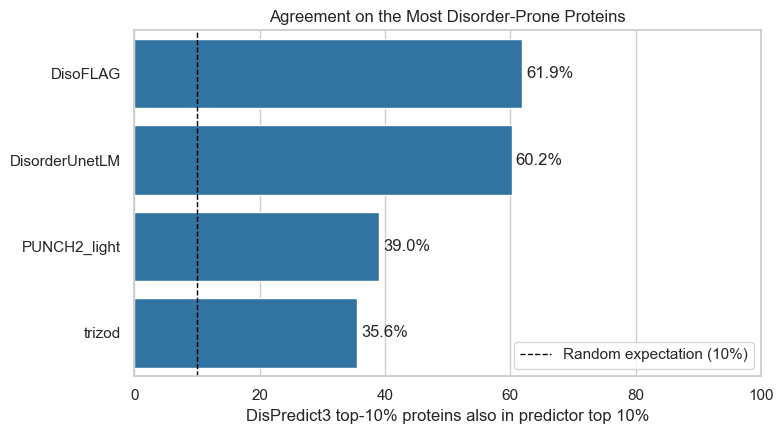

,predictor,common_proteins,proteins_in_top_10_percent,shared_top_10_percent_proteins,top_10_percent_overlap
0,DisoFLAG,20168,2017,1249,61.923649
1,DisorderUnetLM,20596,2060,1240,60.194175
2,PUNCH2_light,20077,2008,783,38.994024
3,trizod,20596,2060,733,35.582524


In [9]:
from IPython.display import display

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.compare_predictors import load_predictions

protein_mean_paths = {
    "DisPredict3": RESULTS / "human_proteome/DisPredict3_native/caid",
    "DisoFLAG": RESULTS / "human_proteome/DisoFLAG/caid",
    "DisorderUnetLM": RESULTS / "human_proteome/DisorderUnetLM/disorder",
    "PUNCH2_light": RESULTS / "human_proteome/punch2_light/disorder",
    "trizod": RESULTS / "human_proteome/UdonPred/trizod",
}

protein_mean_frames = []
for predictor, path in protein_mean_paths.items():
    predictions = load_predictions(path)
    predictor_rows = []
    for protein_id, record in predictions.items():
        finite_scores = record.scores[np.isfinite(record.scores)]
        if len(finite_scores):
            predictor_rows.append(
                {
                    "predictor": predictor,
                    "protein_id": protein_id,
                    "protein_mean": float(np.mean(finite_scores)),
                    "protein_length": len(finite_scores),
                }
            )
    protein_mean_frames.append(pd.DataFrame(predictor_rows))
    del predictions

protein_means = pd.concat(protein_mean_frames, ignore_index=True)

protein_mean_wide = protein_means.pivot(
    index="protein_id",
    columns="predictor",
    values="protein_mean",
)
comparison_predictors = [
    predictor
    for predictor in ["DisoFLAG", "DisorderUnetLM", "PUNCH2_light", "trizod"]
    if predictor in protein_mean_wide
]

top_overlap_rows = []
for predictor in comparison_predictors:
    pair = protein_mean_wide[["DisPredict3", predictor]].dropna()
    top_n = int(np.ceil(0.10 * len(pair)))
    dispredict3_top = set(pair["DisPredict3"].nlargest(top_n).index)
    predictor_top = set(pair[predictor].nlargest(top_n).index)
    shared_top = len(dispredict3_top & predictor_top)
    top_overlap_rows.append(
        {
            "predictor": predictor,
            "common_proteins": len(pair),
            "proteins_in_top_10_percent": top_n,
            "shared_top_10_percent_proteins": shared_top,
            "top_10_percent_overlap": 100 * shared_top / top_n,
        }
    )

dispredict3_top_overlap = pd.DataFrame(top_overlap_rows).sort_values(
    "top_10_percent_overlap",
    ascending=False,
)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=dispredict3_top_overlap,
    x="top_10_percent_overlap",
    y="predictor",
    color="tab:blue",
    ax=ax,
)
ax.axvline(10, color="black", linestyle="--", linewidth=1, label="Random expectation (10%)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
ax.set_xlim(0, 100)
ax.set_xlabel("DisPredict3 top-10% proteins also in predictor top 10%")
ax.set_ylabel("")
ax.set_title("Agreement on the Most Disorder-Prone Proteins")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "dispredict3_top10_protein_overlap.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

display(dispredict3_top_overlap)
dispredict3_top_overlap.to_csv(
    OUTPUT_DIR / "dispredict3_top10_protein_overlap.csv",
    index=False,
)

#### Interpretation

Each bar shows the percentage of DisPredict3's top-10% proteins that the comparison predictor also places in its own top 10%. A higher bar therefore means stronger agreement about which complete proteins are particularly disorder-prone.

The dashed line marks the approximately 10% overlap expected by chance. The plot does not measure accuracy; it only makes the protein-level agreement question concrete.

## Mean Agreement per Predictor

For each predictor, average its pairwise Spearman correlations with every other predictor. High values indicate a predictor close to the shared signal of the complete predictor panel. Low values identify more independent predictors or outliers.

This is a consensus-proximity diagnostic, not an accuracy score: a predictor can disagree with the majority and still be correct.

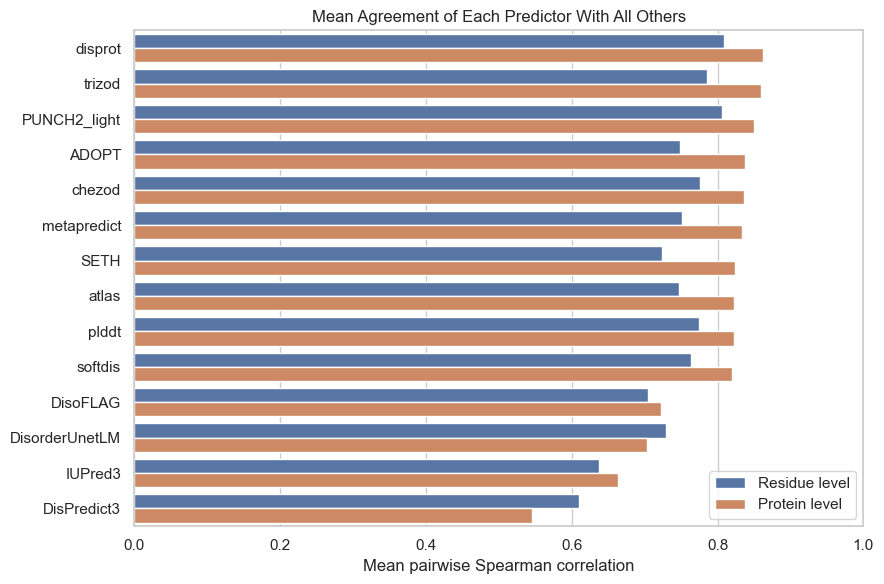

,predictor,mean_residue_spearman,mean_protein_spearman,compared_pairs
9,disprot,0.808710,0.861766,13
13,trizod,0.785459,0.858947,13
5,PUNCH2_light,0.805768,0.849559,13
0,ADOPT,0.748569,0.837312,13
8,chezod,0.775791,0.836904,13
10,metapredict,0.751048,0.833987,13
6,SETH,0.724396,0.823811,13
7,atlas,0.746523,0.822612,13
11,plddt,0.774190,0.822114,13
12,softdis,0.763067,0.820500,13


In [10]:
from IPython.display import display

agreement_columns = ["residue_spearman", "protein_spearman"]

agreement_by_predictor = pd.concat(
    [
        pairwise[["predictor_a", *agreement_columns]].rename(
            columns={"predictor_a": "predictor"}
        ),
        pairwise[["predictor_b", *agreement_columns]].rename(
            columns={"predictor_b": "predictor"}
        ),
    ],
    ignore_index=True,
)

mean_agreement = (
    agreement_by_predictor.groupby("predictor", as_index=False)
    .agg(
        mean_residue_spearman=("residue_spearman", "mean"),
        mean_protein_spearman=("protein_spearman", "mean"),
        compared_pairs=("residue_spearman", "size"),
    )
    .sort_values("mean_protein_spearman", ascending=False)
)

mean_agreement_long = mean_agreement.melt(
    id_vars=["predictor", "compared_pairs"],
    value_vars=["mean_residue_spearman", "mean_protein_spearman"],
    var_name="level",
    value_name="mean_spearman",
)
mean_agreement_long["level"] = mean_agreement_long["level"].map(
    {
        "mean_residue_spearman": "Residue level",
        "mean_protein_spearman": "Protein level",
    }
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    data=mean_agreement_long,
    x="mean_spearman",
    y="predictor",
    hue="level",
    order=mean_agreement["predictor"],
    ax=ax,
)
ax.set_xlim(0, 1)
ax.set_xlabel("Mean pairwise Spearman correlation")
ax.set_ylabel("")
ax.set_title("Mean Agreement of Each Predictor With All Others")
ax.legend(title="")
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "mean_agreement_per_predictor.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

display(mean_agreement)
mean_agreement.to_csv(
    OUTPUT_DIR / "mean_agreement_per_predictor.csv",
    index=False,
)

## Top-10% Protein Overlap Across All Predictors

For each predictor pair, select the 10% of common proteins with the highest mean disorder score and calculate how many proteins occur in both selections.

- 100%: identical top-10% selections
- approximately 10%: overlap expected from unrelated selections
- intermediate values: partial agreement about the most disorder-prone proteins

CheZOD and pLDDT are direction-corrected before ranking because lower native scores indicate more disorder.

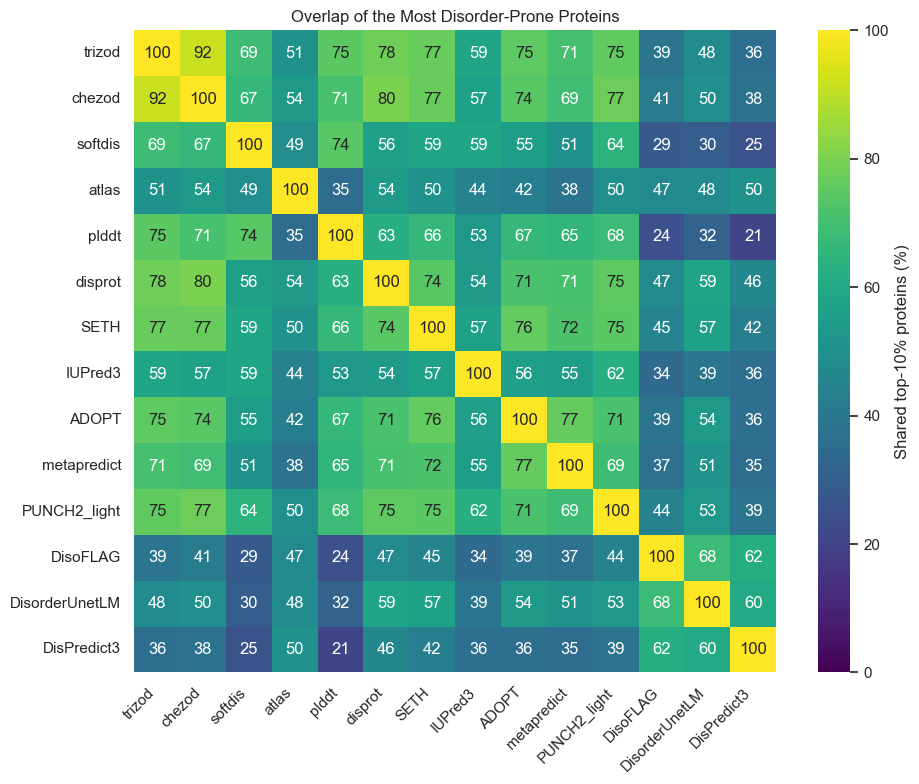

,predictor_a,predictor_b,common_proteins,proteins_per_top_10_percent,shared_top_10_percent_proteins,top_10_percent_overlap
0,trizod,chezod,20659,2066,1895,91.723136
16,chezod,disprot,20659,2066,1658,80.251694
4,trizod,disprot,20659,2066,1608,77.831559
21,chezod,PUNCH2_light,20077,2008,1556,77.490040
5,trizod,SETH,20659,2066,1588,76.863504
...,...,...,...,...,...,...
34,softdis,DisorderUnetLM,20659,2066,613,29.670862
33,softdis,DisoFLAG,20195,2020,576,28.514851
35,softdis,DisPredict3,20596,2060,517,25.097087
52,plddt,DisoFLAG,20195,2020,491,24.306931


In [11]:
from itertools import combinations
from IPython.display import display

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.compare_predictors import load_predictions

predictor_paths = {
    name: ROOT / path
    for name, path in (value.split("=", 1) for value in predictor_args)
}
negated_predictors = {"chezod", "plddt", "adopt"}

protein_mean_series = {}
for predictor, path in predictor_paths.items():
    predictions = load_predictions(path)
    means = {}
    direction = -1.0 if predictor.lower() in negated_predictors else 1.0
    for protein_id, record in predictions.items():
        finite_scores = record.scores[np.isfinite(record.scores)]
        if len(finite_scores):
            means[protein_id] = direction * float(np.mean(finite_scores))
    protein_mean_series[predictor] = pd.Series(means, dtype=float)
    del predictions

all_protein_means = pd.DataFrame(protein_mean_series)
overlap_order = [predictor for predictor in predictor_order if predictor in all_protein_means]
top10_overlap_matrix = pd.DataFrame(
    np.nan,
    index=overlap_order,
    columns=overlap_order,
)
top10_overlap_details = []

for predictor in overlap_order:
    top10_overlap_matrix.loc[predictor, predictor] = 100.0

for predictor_a, predictor_b in combinations(overlap_order, 2):
    pair = all_protein_means[[predictor_a, predictor_b]].dropna()
    top_n = int(np.ceil(0.10 * len(pair)))
    top_a = set(pair[predictor_a].nlargest(top_n).index)
    top_b = set(pair[predictor_b].nlargest(top_n).index)
    shared = len(top_a & top_b)
    overlap_percent = 100 * shared / top_n
    top10_overlap_matrix.loc[predictor_a, predictor_b] = overlap_percent
    top10_overlap_matrix.loc[predictor_b, predictor_a] = overlap_percent
    top10_overlap_details.append(
        {
            "predictor_a": predictor_a,
            "predictor_b": predictor_b,
            "common_proteins": len(pair),
            "proteins_per_top_10_percent": top_n,
            "shared_top_10_percent_proteins": shared,
            "top_10_percent_overlap": overlap_percent,
        }
    )

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    top10_overlap_matrix,
    annot=True,
    fmt=".0f",
    cmap="viridis",
    vmin=0,
    vmax=100,
    square=True,
    cbar_kws={"label": "Shared top-10% proteins (%)"},
    ax=ax,
)
ax.set_title("Overlap of the Most Disorder-Prone Proteins")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "predictor_top10_protein_overlap_heatmap.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

udonpred_predictors = {"trizod", "chezod", "softdis", "atlas", "plddt", "disprot"}
external_predictors = [
    predictor for predictor in overlap_order if predictor not in udonpred_predictors
]
external_top10_overlap_matrix = top10_overlap_matrix.loc[
    external_predictors, external_predictors
]

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    external_top10_overlap_matrix,
    annot=True,
    fmt=".0f",
    cmap="viridis",
    vmin=0,
    vmax=100,
    square=True,
    cbar_kws={"label": "Shared top-10% proteins (%)"},
    ax=ax,
)
ax.set_title("Overlap of the Most Disorder-Prone Proteins\nExternal Predictors Only")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "external_predictor_top10_protein_overlap_heatmap.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()
external_top10_overlap_matrix.to_csv(
    OUTPUT_DIR / "external_predictor_top10_protein_overlap_matrix.csv"
)

top10_overlap_details = pd.DataFrame(top10_overlap_details).sort_values(
    "top_10_percent_overlap",
    ascending=False,
)
top10_overlap_matrix.to_csv(OUTPUT_DIR / "predictor_top10_protein_overlap_matrix.csv")
top10_overlap_details.to_csv(
    OUTPUT_DIR / "predictor_top10_protein_overlap_pairs.csv",
    index=False,
)
display(top10_overlap_details)

### How to Interpret Both Plots

Predictors with high mean agreement and consistently high top-10% overlap form the central consensus group. Predictors with low values in both plots are methodologically more independent. High mean Spearman but lower top-10% overlap means that the overall ranking is similar while the most extreme proteins differ. Lower residue-level than protein-level agreement indicates similar global protein assessments but different local disorder boundaries.

In the current panel, DisProt, TriZOD, PUNCH2_light, ADOPT, CheZOD, metapredict, SETH, ATLAS, pLDDT, and SoftDis form the main high-agreement group. ADOPT, metapredict, and SETH therefore follow the main shared disorder signal despite being external predictors. TriZOD and CheZOD have the strongest top-10% overlap (approximately 92%). IUPred3 is more independent, with lower mean agreement than the main group. DisoFLAG, DisorderUnetLM, and DisPredict3 form another distinct group, with top-10% overlaps of approximately 60-68% among themselves. DisPredict3 has the lowest mean agreement, especially at protein level.

Neither plot determines which predictor is correct; an independent benchmark is required for accuracy.

## Formal Predictor Clustering

The heatmaps above use a fixed display order. Here, average-linkage hierarchical clustering orders predictors from the distance `1 - Spearman`. The colored side bar marks UdonPred models, CAID-style external predictors, and classical external predictors. Clustering is performed separately for pooled residue-level Spearman and protein mean-score Spearman. It describes similarity, not benchmark accuracy.


In [ ]:
from IPython.display import Image, display

GLOBAL_DIR = OUTPUT_DIR / "global_behavior"
required_global_outputs = [
    GLOBAL_DIR / "predictor_clusters_residue.png",
    GLOBAL_DIR / "predictor_clusters_protein.png",
    GLOBAL_DIR / "protein_length_vs_mean_scores.png",
    GLOBAL_DIR / "predictor_qc.csv",
]
if not all(path.exists() for path in required_global_outputs):
    subprocess.run(
        [sys.executable, str(ROOT / "scripts/analyze_global_predictor_behavior.py")],
        cwd=ROOT,
        check=True,
    )

display(Image(filename=str(GLOBAL_DIR / "predictor_clusters_residue.png")))
display(Image(filename=str(GLOBAL_DIR / "predictor_clusters_protein.png")))
group_agreement = pd.read_csv(GLOBAL_DIR / "predictor_group_agreement.csv")
display(group_agreement)


### Cluster Interpretation

The expected method labels are informative but do not define perfectly separated clusters. The six UdonPred models have the strongest within-group agreement (mean residue Spearman 0.85; protein-level Spearman 0.92). DisPredict3, DisoFLAG, and DisorderUnetLM are adjacent at both analysis levels, while PUNCH2_light is closer to parts of the main consensus group. This supports a shared disorder signal plus method-specific subgroups; it does not show that one group is more accurate.


## Training Annotation and Predictor Behavior

For each UdonPred model pair, human-proteome predictor Spearman is compared with the existing exact-overlap annotation estimate. Continuous annotation pairs use Spearman; pairs involving binary DisProt use AUROC. These metrics are shown together only as pair-specific agreement indicators. Point size represents the number of compared annotation residues.


In [ ]:
display(Image(filename=str(GLOBAL_DIR / "annotation_vs_predictor_agreement.png")))
annotation_comparison = pd.read_csv(
    GLOBAL_DIR / "annotation_vs_predictor_agreement.csv"
)
annotation_summary = pd.read_csv(
    GLOBAL_DIR / "annotation_vs_predictor_summary.csv"
)
display(annotation_comparison)
display(annotation_summary)


### Annotation Comparison Interpretation

Among the nine available continuous annotation pairs, annotation agreement and human-proteome model agreement have a descriptive Spearman correlation of 0.60. This is compatible with annotation type influencing learned behavior, but it is not a significance test or causal result. Several points use only one or two overlapping proteins, the pairs are statistically dependent, and DisProt requires a different metric. The result should therefore be presented as a pattern that motivates interpretation, not as evidence of a universal annotation-performance relationship.


## Protein-Length Effects

Native score scales are unsuitable for cross-predictor variance. Each predictor's protein means are therefore converted to within-predictor percentiles. Predictor disagreement is the standard deviation of these percentiles for each protein. Pairwise agreement within a length class is Spearman over protein mean scores, so every protein has equal weight. This differs from pooled residue-level correlation, where long proteins contribute more observations.


In [ ]:
display(Image(filename=str(GLOBAL_DIR / "protein_length_effects.png")))
display(Image(filename=str(GLOBAL_DIR / "protein_length_vs_mean_scores.png")))
length_bins = pd.read_csv(GLOBAL_DIR / "length_bin_summary.csv")
length_effects = pd.read_csv(GLOBAL_DIR / "length_effects_by_predictor.csv")
display(length_bins)
display(length_effects.sort_values("length_vs_mean_score_spearman"))


### Length Interpretation

All four length classes are well populated (2,422 to 8,715 proteins). Predictor disagreement is highest for proteins shorter than 200 residues, followed by proteins of at least 1,000 residues; the middle classes are more consistent. Length effects are predictor-specific: DisPredict3, DisorderUnetLM, and DisoFLAG assign lower mean-score ranks to longer proteins, whereas IUPred3 shows the strongest positive relationship. Consequently, pooled residue-level and equal-protein analyses should both be reported.


## Methodological Quality Control

All scores are oriented so that higher means more disorder. CheZOD, pLDDT, and ADOPT are multiplied by -1 for rank-based comparisons. A universal threshold of 0.5 is not used: bounded scores are not automatically calibrated to the same biological decision boundary, so cross-predictor high-score analyses use within-predictor quantiles.


In [ ]:
predictor_qc = pd.read_csv(GLOBAL_DIR / "predictor_qc.csv")
qc_columns = [
    "predictor", "proteins", "common_proteins_with_reference",
    "length_mismatched_common_proteins",
    "overlap_sequence_mismatched_proteins",
    "score_transform", "cross_predictor_threshold_policy",
]
display(predictor_qc[qc_columns])


### QC Interpretation

UdonPred, IUPred3, SETH, DisorderUnetLM, DisoFLAG, PUNCH2_light, and DisPredict3 have no sequence or length mismatch among shared proteins. ADOPT is truncated for 2,317 proteins, as expected from its input limit, and should not be treated as full-length for those proteins. metapredict has 67 sequence mismatches that require caution for residue-position analyses. Pairwise CSV files report `residue_spearman` as one correlation over all matched residues and `protein_spearman` as a correlation over per-protein mean scores; neither is the mean of per-protein residue correlations.
